# Accuracy assessment of classification maps <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** [ga_ls_landcover_class_cyear_3](https://explorer.dea.ga.gov.au/products/ga_ls_landcover_class_cyear_3)

## Background

Classification models are commonly evaluated using an independent validation dataset to quantify how well predicted classes match observed (or "ground truth") classes. This process is known as **accuracy assessment** and is an essential step in remote sensing and machine learning workflows because it provides an objective measure of the reliability of a classification product.

A standard approach for accuracy assessment is the **confusion matrix** (also known as an error matrix). The confusion matrix compares model predictions against reference labels, summarising the number of samples that were correctly and incorrectly classified. For a binary classification problem, the matrix is composed of:

| | Reference Positive | Reference Negative |
|---|---|---|
| **Predicted Positive** | True Positive (TP) | False Positive (FP) |
| **Predicted Negative** | False Negative (FN) | True Negative (TN) |

The diagonal elements of the matrix represent correctly classified samples, while the off-diagonal elements represent classification errors. By analysing these counts, several useful accuracy metrics can be derived.

### Overall Accuracy

Overall Accuracy (OA) measures the _proportion_ of total validation samples that were correctly classified:

$$
OA = \frac{TP + TN}{TP + TN + FP + FN}
$$

While overall accuracy provides a simple summary of performance, it can be misleading when classes are imbalanced. For this reason, class-specific accuracy metrics are often reported alongside OA.

### User's Accuracy

User's Accuracy (UA) describes the reliability of a mapped class from the perspective of a map user. It answers the question:

> "If a pixel is classified as class X, what is the probability that it is actually class X?"

For a given class:

$$
UA = \frac{\text{Correctly classified samples}}{\text{All samples predicted as that class}}
$$

User's accuracy is equivalent to **precision** in machine learning terminology and is related to **errors of commission** (false positives).

### Producer's Accuracy

Producer's Accuracy (PA) measures how completely a class has been identified. It answers the question:

> "Of all the pixels that truly belong to class X, how many were correctly classified?"

For a given class:

$$
PA = \frac{\text{Correctly classified samples}}{\text{All reference samples of that class}}
$$

Producer's accuracy is equivalent to **recall** (or sensitivity) in machine learning terminology and is related to **errors of omission** (false negatives).

### Unbiased class area estimation 
Olofsson et al. (2014) introduced an approach that combines accuracy assessment with unbiased area estimation. Traditional accuracy metrics alone do not account for the fact that classification errors can systematically overestimate or underestimate the mapped extent of individual classes. The method uses a probability sample of reference observations and error-matrix-derived area weights to adjust mapped class areas for observed omission and commission errors, producing unbiased estimates of 'true' class extent. In addition to correcting area estimates, the approach quantifies sampling uncertainty and provides confidence intervals, making area statistics more robust, transparent, and suitable for reporting and change analysis.


## Description

In this notebook, we use validation datasets to construct a confusion matrix and calculate Overall Accuracy, User's Accuracy, and Producer's Accuracy for each class. These metrics provide a quantitative assessment of model performance and help identify sources of classification error.

Specifically, we will:
1. Create a confusion matrix from an existing validation file that contains both reference ("ground truth") and predictions.
2. Using a dataset that contains ground truth samples, extract class values from DEA Landcover and then create a confusion matrix
3. Discuss and implement methods described by Olofsson et al. (2014) for estimating the area of a class from validation samples, in contrast to mapped area (pixel counting).

## References

* Olofsson, P.; Foody, G. M.; Herold, M.; Stehman, S. V.; Woodcock, C. E.; Wulder, M. A. (2014). *Good practices for estimating area and assessing accuracy of land change*. Remote Sensing of Environment, **148**, 42–57. [doi:10.1016/j.rse.2014.02.015](https://doi.org/10.1016/j.rse.2014.02.015)
* Olofsson, P., Arévalo, P., Espejo, A. B., Green, C., Lindquist, E., McRoberts, R. E., & Sanz, M. J. (2020). Mitigating the effects of omission errors on area and area change estimates. Remote Sensing of Environment, 236, 111492.

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

## Load packages


In [1]:
import datacube
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, "../Tools/")
from dea_tools.classification import collect_training_data
from dea_tools.validation import confusion_matrix_accuracy, estimate_olofsson_area

## Part 1: Create a confusion matrix from an existing validation file

We have an example validation file on disk that we can read in with Pandas. This file contains 1000 Landcover validation samples with both ground truth and prediction samples.  The classification system here is identical to those used for [DEA Landcover Level 3](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/?tab=description), and classes are represented as integers. 

In [2]:
path = "../Supplementary_data/Accuracy_assessment/lc_validation.csv"
val_df = pd.read_csv(path, index_col=0)
val_df.head(3)

,prediction,reference
0,112,112
1,112,112
2,112,111


### Create a confusion matrix

We will use the `dea-tools.validation.confusion_matrix_accuracy` function to create a formatted confusion matrix that includes User's, Producer's, and Overall Accuracy.

This function includes the option to provide `class_names` to replace the integer values with more readable names.

In [3]:
cm_lc = confusion_matrix_accuracy(
    df=val_df,
    ref_col="reference",
    pred_col="prediction",
    class_names=["CTV", "NTV", "NAV", "AS", "NS", "Water"],
)

cm_lc

Predicted,CTV,NTV,NAV,AS,NS,Water,Total,Producer's
Actual,,,,,,,,
CTV,59.00,15.00,0.00,0.0,1.00,0.00,75.0,78.67
NTV,31.00,467.00,2.00,0.0,76.00,0.00,576.0,81.08
NAV,0.00,3.00,53.00,0.0,0.00,2.00,58.0,91.38
AS,0.00,6.00,0.00,26.0,16.00,0.00,48.0,54.17
NS,2.00,27.00,0.00,0.0,162.00,2.00,193.0,83.94
Water,0.00,3.00,0.00,0.0,3.00,44.00,50.0,88.00
Total,92.00,521.00,55.00,26.0,258.00,48.00,1000.0,NaN
User's,64.13,89.64,96.36,100.0,62.79,91.67,NaN,81.10


### Interpretation of Accuracy Statistics

The confusion matrix shows an overall accuracy of 81.1%, indicating that 811 out of 1,000 validation samples were classified correctly. Most classes exhibit reasonably strong performance, with the majority of observations concentrated along the diagonal of the matrix, which represents correct classifications.

User's Accuracy (UA) describes the reliability of each predicted class. The highest UA is observed for **AS-artificial surfaces (100%)**, meaning every pixel predicted as AS was correct. **NAV-natural aquatic (96.36%)** and **Water (91.67%)** also demonstrate high reliability. In contrast, **CTV-cultivated (64.13%)** and **NS-natural bare (62.79%)** have lower UAs, indicating that predictions for these classes are more likely to include commission errors (false positives).

Producer's Accuracy (PA) measures how completely each class is identified. **NAV-natural aquatic (91.38%)** and **Water (88.00%)** have high producer's accuracies, meaning most reference samples of these classes were correctly detected. **AS-artificial surfaces** has the lowest PA (54.17%), indicating that nearly half of the actual AS samples were misclassified as other classes, particularly NS.

The largest sources of confusion occur between **NTV-natural terresterial vegetation and NS-natural bare** (76 samples), **CTV-cultivated and NTV-natural terresterial vegetation** (31 samples), and **AS and NS** (16 samples). These patterns suggest that these class pairs share similar characteristics and may be more difficult for the classifiers to distinguish.

## Part 2: Extract class values from the datacube

In this next example, we take a dataset that contains ground truth values (in this example crop/non-crop samples over Western Australia) and extract predicted class values from the datacube. This demonstrates one way we might extract prediction samples to create a complete validation file. For demonstration purposes, we will extract the "CTV-cultivated" values from DEA Landcover as that class approximately aligns with the example reference crop/non-crop samples.

To extract the samples, we will use the `dea-tools.classification.collect_training_data` function, for more information on how to use this function see the [Collect_training_and_validation_data notebook](Collect_training_and_validation_data.ipynb). 

In [4]:
# Our samples are stored as a geojson file
path = "../Real_world_examples/Scalable_machine_learning/data/crop_training_WA.geojson"
gdf = gpd.read_file(path)

Show the extent of the ground-truth samples. As you can see, they cover the extent of Western Australia

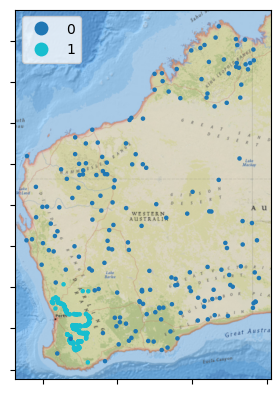

In [5]:
fig, ax = plt.subplots(1, 1)
gdf.plot(column="class", legend=True, categorical=True, markersize=5, ax=ax)
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.NatGeoWorldMap,
    crs="EPSG:4326",
    attribution="",
    attribution_size=1,
)
ax.set_yticklabels([])
ax.set_xticklabels([]);

Now collect the data, this will take about 1 min to run.

In [6]:
# Generate a datacube query object
dc_query = {
    "time": "2024",
    "resolution": (-30, 30),
    "output_crs": "EPSG:3577",
}


# function for extracting landcover
def extract_landcover_values(query):
    dc = datacube.Datacube(app="load-landcover")
    ds = dc.load(
        product="ga_ls_landcover_class_cyear_3", measurements=["level3"], **query
    )
    return ds


# for each validation sample run the landcover function
df = collect_training_data(
    gdf=gdf,
    dc_query=dc_query,
    feature_func=extract_landcover_values,
    field="class",
    ncpus=2,
)

  0%|          | 0/430 [00:00<?, ?it/s]

Percentage of possible fails after run 1 = 0.0 %
Removed 0 rows with NaNs or Infs in numeric columns
Output shape: (430, 2)


Reclassify the DEA Land Cover samples such that pixels with a value of 111 (CTV) are assigned a value of 1, while all other classes are assigned a value of 0. This converts the DEA Land Cover classes into a binary crop/non-crop classification and harmonises them with the ground-truth datasets, where samples are labelled as 1 (crop) and 0 (non-crop).

In [7]:
# reclassify samples
df["level3"] = np.where(df["level3"] == 111, 1, 0)

# tidy up column names
df = df.reset_index().rename({"class": "reference", "level3": "prediction"}, axis=1)

### Create a binary confusion matrix

In [8]:
cm_crop = confusion_matrix_accuracy(
    df=df,
    ref_col="reference",
    pred_col="prediction",
    class_names=["crop", "non-crop"],
    class_order=[1, 0],
)

cm_crop

Predicted,crop,non-crop,Total,Producer's
Actual,,,,
crop,191.0,59.00,250.0,76.40
non-crop,9.0,171.00,180.0,95.00
Total,200.0,230.00,430.0,NaN
User's,95.5,74.35,NaN,84.19


### Interpretation of Accuracy Statistics

The binary confusion matrix has an overall accuracy of 84.2%, indicating good agreement between the predicted and reference crop/non-crop classes.

The **crop class** has a high UA (95.5%), meaning that predictions labeled as crop are usually correct. However, its PA (76.4%) is lower, showing that some true crop samples were missed and classified as non-crop (high omission error or false negatives).

Overall, the classifier is conservative in its crop predictions for Western Australia, producing few false crop detections but missing some genuine crop samples.

## Part 3: Unbiased area estimation using the Olofsson et al. (2014) method

The `dea-tools.validation.estimate_olofsson_area()` function implements the area estimation approach recommended by Olofsson et al. (2014) for land cover and land change accuracy assessment.  

### A simple worked example
Below, we outline the logic of this approach with a simplified example considering crop/non-crop validation samples and the following _mapped_ areas (say from a classified map):

| Class | Mapped Area (ha) |
|---------|---------:|
| Crop | 1,000,000 |
| No Crop | 9,000,000 |
| Total | 10,000,000 |

If we report these values directly, we are implicitly assuming that every mapped pixel has been classified correctly (i.e. PA=100%, UA=100%).

In reality, some pixels mapped as crop will actually be non-crop, and some pixels mapped as non-crop will actually be crop. Just as we saw in the previous section of this notebook where classification accuracy was only 84.2 %.  The purpose of the validation sample is to estimate these classification errors and adjust the area estimates accordingly.

For each mapped class \(i\), the mapped area proportion is:

$$
W_i = \frac{A_{m,i}}{A_{\text{total}}}
$$

where:

* $A_{m,i}$ is the mapped area of class $i$
- $A_{\mathrm{total}}$ is the total mapped area

These area proportions are used as weights when scaling the validation sample to represent the entire map. We can now apply this to the simplified crop/no-crop example.

### Example reference samples

| Map Class | Reference crop | Reference non-crop | Total |
|------------|---------------:|------------------:|------:|
| crop       | 80 | 20 | 100 |
| non-crop    | 5  | 95 | 100 |
| **Total**  | **85** | **115** | **200** |

In this validation set, of the 100 reference crop samples, 80 are mapped correctly, this suggests that only 80% of the pixels mapped as crop are actually crop.

The crop stratum therefore contributes:

$$
1,000,000 \times \frac{80}{100}=
800,000 \text{ ha}
$$

For non-crop, validation sample indicates that 5% on non-crop samples are actually crop (5/100). The non-crop stratum therefore contributes:

$$
9,000,000 \times \frac{5}{100}=
450,000 \text{ ha}
$$

to the estimated crop area.

### Estimating the corrected area

To estimate the true crop area, we add all contributions assigned to the crop reference class:

$$
800,000 + 450,000=
1,250,000 \text{ ha}
$$

If we do this for both classes, then we end up with the same table as above but now containing our Olofsson-adjusted area-proportions in area units.

| Map Class | Reference crop | Reference non-crop | Total |
|------------|---------------:|------------------:|------:|
| crop       | 800,000 | 200,000 | 1,000,000 |
| non-crop    | 450,000  | 8,550,000 | 9,000,000 |
| **Total**  | **1,250,000** | **8,750,000** | **10,000,000** |

In effect, the Olofsson estimator is saying:

> Based on the validation sample, some of the area mapped as crop should really belong to non-crop, and some of the area mapped as non-crop should really belong to crop.

### Uncertainty estimation

Because the reference classification is available only for a sample, the estimated areas are subject to sampling uncertainty.  The Olofsson method also computes:

1. Estimated area proportion for each class.
2. Standard error of the estimated proportion.
3. Standard error of the estimated area.
4. Approximate 95% confidence intervals

---

## Part 3a: Adjusted area for cropping example

Let's implement the function `dea-tools.validation.estimate_olofsson_area()` to estimate the 'true' area of the cropping in the example from Part 2.

For this, we will make up some mapped area numbers.

In [9]:
# make up some example area numbers in km2
crop_area = 10000
noncrop_area = 90000

# create a dataframe with the areas
crop_map_area_df = pd.DataFrame(
    {"class": ["crop", "non-crop"], "map area (km²)": [crop_area, noncrop_area]}
)

crop_map_area_df

,class,map area (km²)
0,crop,10000
1,non-crop,90000


#### Calculate the adjusted areas based on the confusion matrix

We recommend always creating the confusion matrix dataframe using `dea-tools.validaton.confusion_matric_accuracy` function as the `estimate_olofsson_area` assumes the confusion matrix class labels are in the index.

In [10]:
adjusted_area_crop = estimate_olofsson_area(
    confusion_df=cm_crop,  # pass in our previous confusion matrix
    map_area_df=crop_map_area_df,  # map areas with the same classes as the cm
    class_col="class",
    area_col="map area (km²)",
)

adjusted_area_crop

,class,mapped_area,mapped_area_proportion,estimated_area,estimated_area_proportion,standard_error_area,standard_error_proportion,ci_lower,ci_upper,ci_half_width
0,crop,10000.0,0.1,32636.956522,0.32637,2601.447271,0.026014,27538.119871,37735.793173,5098.836651
1,non-crop,90000.0,0.9,67363.043478,0.67363,2601.447271,0.026014,62264.206827,72461.880129,5098.836651


### Plot the differences in area calculations
If we show this as a simple table like in the worked example above, our adjusted areas look like such:

| Map Class | Reference crop | Reference non-crop | Total |
|------------|---------------:|------------------:|------:|
| crop       | 9,550 | 450 | 10,000|
| non-crop    | 23,087  | 66,913 | 90,000 |
| **Total**  | **32,637** | **67,363** | **100,000** |


As you can see, owing to the relatively high omission errors (Producer's Accuracy was only ~76%), our **adjusted area in substantially higher than the mapped area**, and the inverse is true of non-crop area (since this is a simple binary case).

This same data is plotted below as a bar graph with standard errors. Note that the standard errors on these plots are at the 95 % confidence interval. For a different interval, this can be adjusted using the `z` parameter in the `estimate_olofsson_area` function.

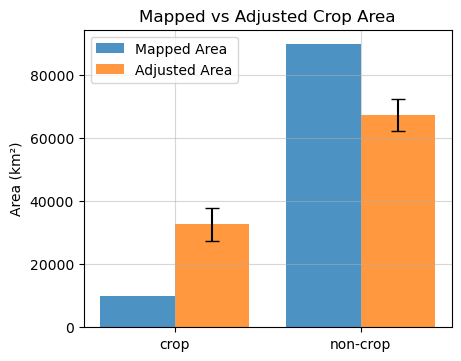

In [11]:
fig, ax = plt.subplots(figsize=(4.5, 3.5), layout="constrained")
# Position of bars
x = np.arange(len(adjusted_area_crop))
width = 0.4

# Mapped area bars
ax.bar(
    x - width / 2,
    adjusted_area_crop["mapped_area"],
    width,
    label="Mapped Area",
    alpha=0.8,
)

# Adjusted area bars with confidence intervals
ax.bar(
    x + width / 2,
    adjusted_area_crop["estimated_area"],
    width,
    label="Adjusted Area",
    alpha=0.8,
    yerr=adjusted_area_crop["ci_half_width"],
    capsize=5,
    error_kw={"elinewidth": 1.5},
)

ax.set_xticks(x)
ax.set_xticklabels(adjusted_area_crop["class"])
ax.set_ylabel("Area (km²)")
ax.grid(alpha=0.5)
ax.set_title("Mapped vs Adjusted Crop Area")
ax.legend();

### Effects of omission errors on area estimates
This example above highlights a **limitation of the unbiased area estimation approach**, namely that omission errors in a dominant map class can have a disproportionate influence on adjusted area estimates. In this example, crop has a producer's accuracy of only 76.4%, meaning that many reference crop samples were mapped as non-crop. Because the non-crop class occupies most of the landscape (90,000 km²), these omissions receive a large area weight, inflating the adjusted crop area estimate from 10,000 km² to 32,637 km². While the estimate is statistically valid, large omission errors can substantially increase uncertainty and make the results difficult to interpret.

One means for mitigating this effect is through improved stratification. [Olofsson et al. (2020)](https://www.sciencedirect.com/science/article/pii/S0034425719305115#bib16) recommend splitting large stable strata using ancillary information, such as a buffer around mapped target-class pixels, so that likely omission errors are contained within a smaller stratum with lower area weight. For example, creating a 1-3 pixel buffer around mapped crop areas and treating the buffer as a separate sampling stratum can reduce the influence of omitted crop samples that occur near crop boundaries, leading to more precise area estimates.


## Part 3b: Adjusted area for Landcover example

In this example, we will apply the same approach as above but instead using the reference labels and confusion matrix for the Landcover example from Part 1, along with real-world mapped class areas extracted from DEA Landcover for the entire Australian continent for the year 2015.

In [12]:
# Open the class areas and rename the columns
lc_map_areas_2015 = pd.read_csv(
    "../Supplementary_data/Accuracy_assessment/lc_v2_level3_classarea_2015.csv",
    index_col=0,
)
lc_map_areas_2015 = lc_map_areas_2015.reset_index().rename({"index": "class"}, axis=1)

# rename integers to class names so the next function works
class_names = ["CTV", "NTV", "NAV", "AS", "NS", "Water"]
class_int = [111, 112, 124, 215, 216, 220]
class_lookup = dict(zip(class_int, class_names))
lc_map_areas_2015["class"] = lc_map_areas_2015["class"].map(class_lookup)
lc_map_areas_2015

,class,map area (km²)
0,CTV,5.970757e+05
1,NTV,4.583601e+06
2,NAV,1.010641e+04
3,AS,5.118090e+03
4,NS,2.457378e+06
5,Water,3.422026e+04


In [13]:
adjusted_area_lc = estimate_olofsson_area(
    confusion_df=cm_lc,
    map_area_df=lc_map_areas_2015,
    class_col="class",
    area_col="map area (km²)",
)

adjusted_area_lc

,class,mapped_area,mapped_area_proportion,estimated_area,estimated_area_proportion,standard_error_area,standard_error_proportion,ci_lower,ci_upper,ci_half_width
0,CTV,5.970757e+05,0.077668,5.243974e+05,0.068214,46061.125245,0.005992,4.341176e+05,6.146772e+05,90279.805481
1,NTV,4.583601e+06,0.596241,5.033960e+06,0.654824,97527.195910,0.012686,4.842807e+06,5.225113e+06,191153.303983
2,NAV,1.010641e+04,0.001315,3.755784e+04,0.004886,15243.575399,0.001983,7.680434e+03,6.743525e+04,29877.407783
3,AS,5.118090e+03,0.000666,2.102998e+05,0.027356,42740.341880,0.005560,1.265287e+05,2.940709e+05,83771.070086
4,NS,2.457378e+06,0.319659,1.794948e+06,0.233489,86944.912913,0.011310,1.624536e+06,1.965360e+06,170412.029310
5,Water,3.422026e+04,0.004451,8.633583e+04,0.011231,22433.268858,0.002918,4.236662e+04,1.303050e+05,43969.206961


### Plot adjusted areas for Landcover


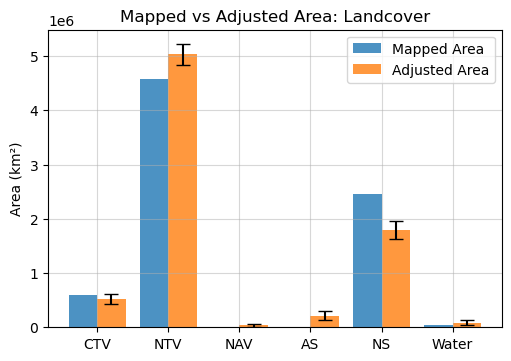

In [14]:
fig, ax = plt.subplots(figsize=(5, 3.5), layout="constrained")
x = np.arange(len(adjusted_area_lc))
width = 0.4

ax.bar(
    x - width / 2,
    adjusted_area_lc["mapped_area"],
    width,
    label="Mapped Area",
    alpha=0.8,
)

ax.bar(
    x + width / 2,
    adjusted_area_lc["estimated_area"],
    width,
    label="Adjusted Area",
    alpha=0.8,
    yerr=adjusted_area_lc["ci_half_width"],
    capsize=5,
    error_kw={"linewidth": 1.5},
)

ax.set_xticks(x)
ax.set_xticklabels(adjusted_area_lc["class"])
ax.set_ylabel("Area (km²)")
ax.grid(alpha=0.5)
ax.set_title("Mapped vs Adjusted Area: Landcover")
ax.legend();

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** August 2026

**Compatible datacube version:** 

In [15]:
print(datacube.__version__)

1.9.10


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->